In [1]:
# **1. Import Libraries**
import numpy as np
import geopandas as gpd
import cv2
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models

# **2. Function to Load and Preprocess PNG Image**
def load_and_preprocess(image_path):
    """ Load PNG image, remove black spots, and normalize """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Error: Could not open {image_path}")

    # Replace black pixels (0 values) with local mean to reduce black spots
    img[img == 0] = np.nan
    mask = np.isnan(img)
    img[mask] = np.nanmean(img)

    # Normalize the image (0-1)
    img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img))
    
    return img

# **3. Function to Extract Shoreline**
def extract_shoreline(img):
    """ Extract shoreline using Canny edge detection """
    img_uint8 = np.uint8(img * 255)

    # Apply Canny edge detection
    edges = cv2.Canny(img_uint8, 50, 150)

    # Find contours and select the largest one (shoreline)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        raise ValueError("No shoreline detected!")

    largest_contour = max(contours, key=cv2.contourArea)

    # Convert to coordinate list
    shoreline_coords = [(int(pt[0][0]), int(pt[0][1])) for pt in largest_contour]

    return shoreline_coords

In [2]:
!pip install xgboost

^C
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/150.0 MB 2.1 MB/s eta 0:01:11
   ---------------------------------------- 0.3/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.3/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.3/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.3/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.3/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.3/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.4/150.0 MB 1.0 MB/s eta 0:02:23
   ---------------------------------------- 0.4/150.0 MB 1.0 MB/s eta 0:02:23
   ---------------------------------------- 0.4/150.0 MB 1.0 MB/s eta 0:02:23
   ---------------------------------------- 0.4/150.0 MB 1.0 MB/s eta 0:02:

In [2]:
# **4. U-Net Model**
from tensorflow.keras.layers import Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D
from tensorflow.keras.optimizers import Adam

def build_unet_model(input_shape):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c2 = MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)

    # Decoder
    u1 = UpSampling2D((2, 2))(b)
    u1 = Conv2D(64, (3, 3), activation='relu', padding='same')(u1)

    u2 = UpSampling2D((2, 2))(u1)
    u2 = Conv2D(32, (3, 3), activation='relu', padding='same')(u2)

    # Output layer with shape consistency
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(u2)

    # Cropping to ensure output matches label shape
    outputs = Cropping2D(cropping=((0, 0), (0, 1)))(outputs)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    return model

# **5. Prepare Data for U-Net**
def load_and_preprocess(image_path, target_size=(156, 220)):
    """ Load image, resize, remove black spots, normalize """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Error: Could not open {image_path}")

    # Resize to target dimensions
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    # Convert to float for NaN compatibility
    img = img.astype(np.float32)

    # Handle black spots by replacing 0 values with local mean
    black_mask = (img == 0)

    # Avoid NaN propagation in all-black regions
    if np.all(black_mask):
        raise ValueError(f"Error: Image {image_path} is completely black!")

    # Replace black pixels with the local mean
    img[black_mask] = np.nan
    mask = np.isnan(img)
    img[mask] = np.nanmean(img)

    # Normalize the image (0-1)
    img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img))

    return img

# Load and preprocess images with the same dimensions
image_paths = [
    "Landsat_CloudFree_2010_Month_1.jpg",
    "Landsat_CloudFree_2013_Month_3.jpg",
    "Landsat_CloudFree_2014_Month_1.jpg",
    "Landsat_CloudFree_2015_Month_1.jpg",
    "Landsat_CloudFree_2016_Month_1.jpg",
    "Landsat_CloudFree_2018_Month_1.jpg",
    "Landsat_CloudFree_2019_Month_1.jpg"
]

X, Y = prepare_unet_data(image_paths)

# Split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Build and train U-Net model
unet_model = build_unet_model(X_train[0].shape)
history = unet_model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=20, batch_size=4)

# Evaluate the model
unet_loss, unet_accuracy = unet_model.evaluate(X_test, Y_test)
print(f"U-Net Loss: {unet_loss:.4f}, Accuracy: {unet_accuracy:.4f}")

NameError: name 'prepare_unet_data' is not defined

In [10]:
# ✅ Import the necessary Keras modules
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D
from tensorflow.keras.optimizers import Adam


In [ ]:
"Landsat_CloudFree_2010_Month_1.jpg",
    "Landsat_CloudFree_2013_Month_3.jpg",
    "Landsat_CloudFree_2014_Month_1.jpg",
    "Landsat_CloudFree_2015_Month_1.jpg",
    "Landsat_CloudFree_2016_Month_1.jpg",
    "Landsat_CloudFree_2018_Month_1.jpg",
    "Landsat_CloudFree_2019_Month_1.jpg"

## first method

In [50]:
import os
import cv2

# ✅ Debug path checking
image_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
mask_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"
target_shape = (256, 256)

# ✅ Validate and print paths
for img_name in os.listdir(image_dir):
    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    # ✅ Check if files exist
    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
    if not os.path.exists(mask_path):
        print(f"❌ Mask not found: {mask_path}")

    # ✅ Check if images and masks are loading
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"⚠️ Failed to load image: {img_path}")
    if mask is None:
        print(f"⚠️ Failed to load mask: {mask_path}")


In [51]:
import os
import cv2
import numpy as np

# Directories
image_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
mask_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"
output_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\Output for rameshwaram"  # Output folder

# Target dimensions
TARGET_SHAPE = (256, 256)

# ✅ Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

def standardize_and_save(image_dir, mask_dir, output_dir, target_shape):
    """
    Standardizes all images and masks to the same dimensions.
    """
    standardized_images = []
    standardized_masks = []

    image_paths = os.listdir(image_dir)

    for img_name in image_paths:
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name)

        if not os.path.exists(mask_path):
            print(f"⚠️ No matching mask for {img_name}. Skipping.")
            continue

        # ✅ Load image and mask
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print(f"❌ Failed to load image/mask: {img_name}")
            continue

        # ✅ Resize image and mask
        img_resized = cv2.resize(img, target_shape)
        mask_resized = cv2.resize(mask, target_shape)

        # ✅ Normalize image and mask
        img_normalized = img_resized / 255.0
        mask_normalized = mask_resized / 255.0

        # Save preprocessed image and mask
        cv2.imwrite(os.path.join(output_dir, f"img_{img_name}"), (img_normalized * 255).astype(np.uint8))
        cv2.imwrite(os.path.join(output_dir, f"mask_{img_name}"), (mask_normalized * 255).astype(np.uint8))

        standardized_images.append(img_normalized)
        standardized_masks.append(mask_normalized)

    print(f"\n✅ Processed {len(standardized_images)} images and masks.")
    
    return np.array(standardized_images), np.array(standardized_masks)

# Execute standardization
images, masks = standardize_and_save(image_dir, mask_dir, output_dir, TARGET_SHAPE)



✅ Processed 38 images and masks.


In [52]:
import numpy as np
import random
import cv2
from sklearn.model_selection import train_test_split

# ✅ Parameters
IMG_HEIGHT, IMG_WIDTH = TARGET_SHAPE

# ✅ Lightweight Augmentation Functions
def augment_image(img):
    """
    Applies random augmentations (flip, rotate, brightness, contrast) on a 2D image.
    """
    # Flip horizontally
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Flip vertically
    if random.random() > 0.5:
        img = cv2.flip(img, 0)

    # Rotate by 90, 180, or 270 degrees
    rotations = [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]
    if random.random() > 0.5:
        img = cv2.rotate(img, random.choice(rotations))

    # Adjust brightness and contrast
    alpha = random.uniform(0.8, 1.2)  # Contrast
    beta = random.randint(-30, 30)    # Brightness
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    return img

# ✅ Preprocessing function
def preprocess_and_augment(images, masks):
    """
    Preprocesses images and masks: normalization, resizing, and augmentation.
    """
    aug_images = []
    aug_masks = []

    for img, mask in zip(images, masks):
        # Resize to ensure consistency
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))

        # Normalize to [0, 1]
        img = img / 255.0
        mask = mask / 255.0

        # Apply augmentation
        img_aug = augment_image((img * 255).astype(np.uint8))
        mask_aug = augment_image((mask * 255).astype(np.uint8))

        # Normalize again
        img_aug = img_aug / 255.0
        mask_aug = mask_aug / 255.0

        aug_images.append(img_aug)
        aug_masks.append(mask_aug)

    # ✅ Convert to numpy arrays
    aug_images = np.array(aug_images)
    aug_masks = np.array(aug_masks)

    # ✅ Split into train/test sets
    X_train, X_test, Y_train, Y_test = train_test_split(
        aug_images, aug_masks, test_size=0.2, random_state=42
    )

    print("\n✅ Dataset shapes after preprocessing:")
    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
    print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

    return X_train, X_test, Y_train, Y_test

# ✅ Execute preprocessing
X_train, X_test, Y_train, Y_test = preprocess_and_augment(images, masks)



✅ Dataset shapes after preprocessing:
X_train: (30, 256, 256, 3), Y_train: (30, 256, 256)
X_test: (8, 256, 256, 3), Y_test: (8, 256, 256)


In [53]:
import numpy as np
import random
import cv2
from sklearn.model_selection import train_test_split

# ✅ Parameters
IMG_HEIGHT, IMG_WIDTH = TARGET_SHAPE

# ✅ Lightweight Augmentation Functions
def augment_image(img):
    """
    Applies random augmentations (flip, rotate, brightness, contrast) on a 2D image.
    """

    # Adjust brightness and contrast
    alpha = random.uniform(0.8, 1.2)  # Contrast
    beta = random.randint(-30, 30)    # Brightness
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    return img

# ✅ Preprocessing function
def preprocess_and_augment(images, masks):
    """
    Preprocesses images and masks: normalization, resizing, and augmentation.
    """
    aug_images = []
    aug_masks = []

    for img, mask in zip(images, masks):
        # Resize to ensure consistency
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))

        # Normalize to [0, 1]
        img = img / 255.0
        mask = mask / 255.0

        # Apply augmentation
        img_aug = augment_image((img * 255).astype(np.uint8))
        mask_aug = augment_image((mask * 255).astype(np.uint8))

        # Normalize again
        img_aug = img_aug / 255.0
        mask_aug = mask_aug / 255.0

        aug_images.append(img_aug)
        aug_masks.append(mask_aug)

    # ✅ Convert to numpy arrays
    aug_images = np.array(aug_images)
    aug_masks = np.array(aug_masks)

    # ✅ Split into train/test sets
    X_train, X_test, Y_train, Y_test = train_test_split(
        aug_images, aug_masks, test_size=0.2, random_state=42
    )

    print("\n✅ Dataset shapes after preprocessing:")
    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
    print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

    return X_train, X_test, Y_train, Y_test

# ✅ Execute preprocessing
X_train, X_test, Y_train, Y_test = preprocess_and_augment(images, masks)



✅ Dataset shapes after preprocessing:
X_train: (30, 256, 256, 3), Y_train: (30, 256, 256)
X_test: (8, 256, 256, 3), Y_test: (8, 256, 256)



📌 Displaying Mask Images...


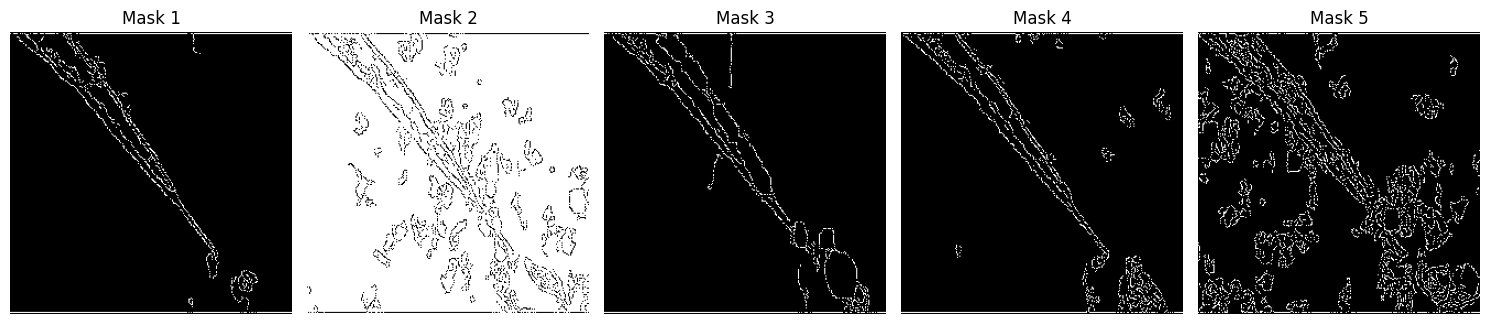

In [54]:
import matplotlib.pyplot as plt

def visualize_masks(X, Y, num_samples=5):
    """
    Visualizes only the mask images.
    """
    num_samples = min(num_samples, len(Y))
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i in range(num_samples):
        mask = (Y[i] * 255).astype(np.uint8)
        axes[i].imshow(mask, cmap='gray')
        axes[i].set_title(f"Mask {i+1}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# ✅ Display mask images
print("\n📌 Displaying Mask Images...")
visualize_masks(X_test, Y_test, num_samples=5)


✅ Mask saved: Landsat_CloudFree_2010_Month_1.jpg
✅ Mask saved: Landsat_CloudFree_2013_Month_3.jpg
✅ Mask saved: Landsat_CloudFree_2014_Month_1.jpg
✅ Mask saved: Landsat_CloudFree_2015_Month_1.jpg
✅ Mask saved: Landsat_CloudFree_2016_Month_1.jpg
✅ Mask saved: Landsat_CloudFree_2018_Month_1.jpg
✅ Mask saved: Landsat_CloudFree_2019_Month_1.jpg
✅ Mask saved: Landsat_CloudFree_2020_Month_11.jpg
✅ Mask saved: Landsat_CloudFree_2020_Month_12.jpg
✅ Mask saved: Landsat_CloudFree_2020_Month_2.jpg
✅ Mask saved: Landsat_CloudFree_2020_Month_4.jpg
✅ Mask saved: Landsat_CloudFree_2020_Month_5.jpg
✅ Mask saved: Landsat_CloudFree_2020_Month_6.jpg
✅ Mask saved: Landsat_CloudFree_2021_Month_11.jpg
✅ Mask saved: Landsat_CloudFree_2021_Month_3.jpg
✅ Mask saved: Landsat_CloudFree_2021_Month_4.jpg
✅ Mask saved: Landsat_CloudFree_2021_Month_5.jpg
✅ Mask saved: Landsat_CloudFree_2021_Month_6.jpg
✅ Mask saved: Landsat_CloudFree_2021_Month_7.jpg
✅ Mask saved: Landsat_CloudFree_2022_Month_2.jpg
✅ Mask saved: Lan

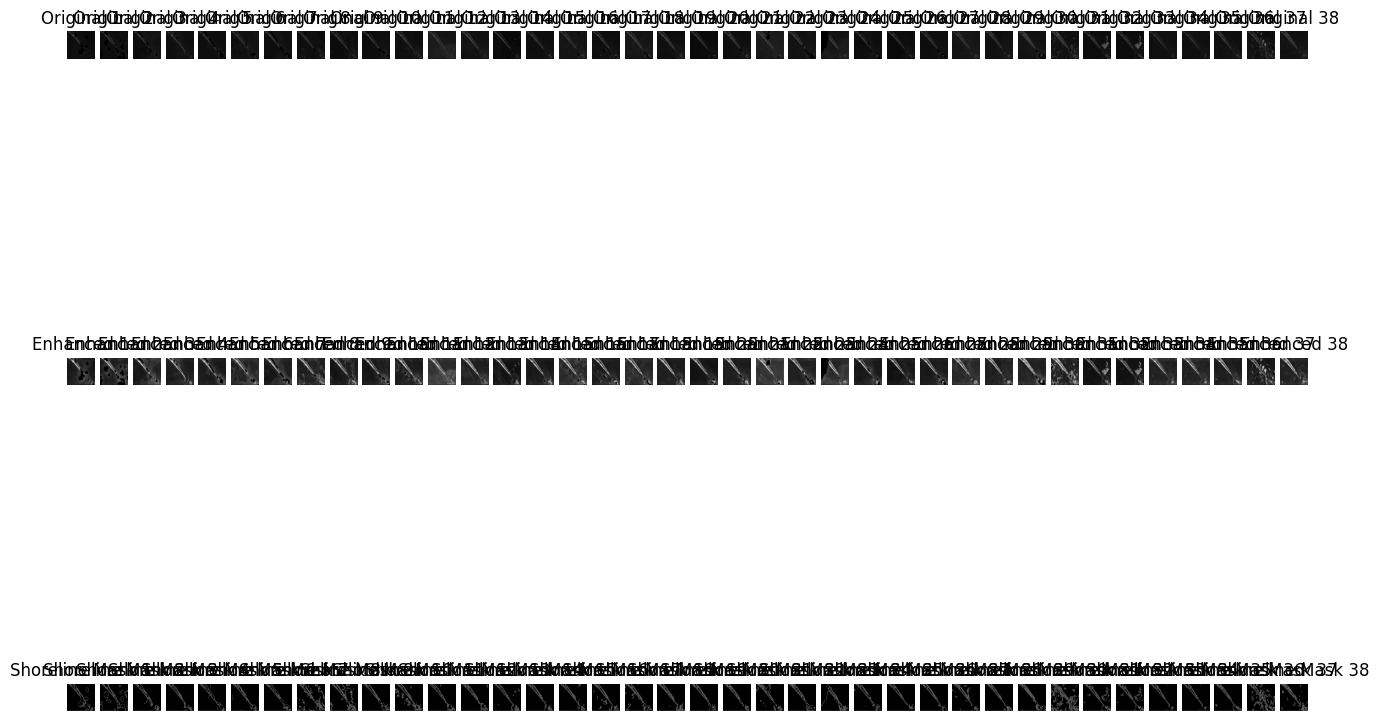

In [55]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

# ✅ Directories
input_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"        
mask_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram" 

# ✅ Create mask folder if it doesn't exist
os.makedirs(mask_dir, exist_ok=True)

# ✅ Target image size
image_size = (256, 256)

# ✅ Function for shoreline detection
def shoreline_detection(image):
    """Preprocess image and apply shoreline detection."""
    img_resized = cv2.resize(image, image_size)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Canny edge detection
    edges = cv2.Canny(enhanced, 30, 100)

    return img_resized, enhanced, edges

# ✅ Apply shoreline detection and save masks
for img_path in glob(f"{input_dir}/*.jpg"):
    img = cv2.imread(img_path)

    # Apply shoreline detection
    resized, enhanced, edges = shoreline_detection(img)

    # Save the mask
    mask_path = os.path.join(mask_dir, os.path.basename(img_path))
    cv2.imwrite(mask_path, edges)

    print(f"✅ Mask saved: {os.path.basename(img_path)}")

# ✅ Load all image and mask paths
image_paths = glob(f"{input_dir}/*.jpg")
mask_paths = glob(f"{mask_dir}/*.jpg")

# ✅ Handle cases with fewer than 4 images
num_images = min(len(image_paths), len(mask_paths))
if num_images == 0:
    print("❌ No images or masks found.")
else:
    # ✅ Visualization
    fig, axes = plt.subplots(3, num_images, figsize=(16, 12))

    for i in range(num_images):
        img = cv2.imread(image_paths[i])
        mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)

        # Apply shoreline detection again for visualization
        resized, enhanced, edges = shoreline_detection(img)

        # Original Image
        axes[0, i].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f"Original {i+1}")
        axes[0, i].axis('off')

        # Enhanced Contrast
        axes[1, i].imshow(enhanced, cmap='gray')
        axes[1, i].set_title(f"Enhanced {i+1}")
        axes[1, i].axis('off')

        # Shoreline Mask
        axes[2, i].imshow(mask, cmap='gray')
        axes[2, i].set_title(f"Shoreline Mask {i+1}")
        axes[2, i].axis('off')

    
    plt.show()


## use NDWI

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 256, 256, 64)      1792      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 128, 128, 64)     0         
 2D)                                                             
                                                                 
 batch_normalization_6 (Batc  (None, 128, 128, 64)     256       
 hNormalization)                                                 
                                                                 
 conv2d_9 (Conv2D)           (None, 128, 128, 128)     73856     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 64, 64, 128)      0         
 2D)                                                             
                                                      

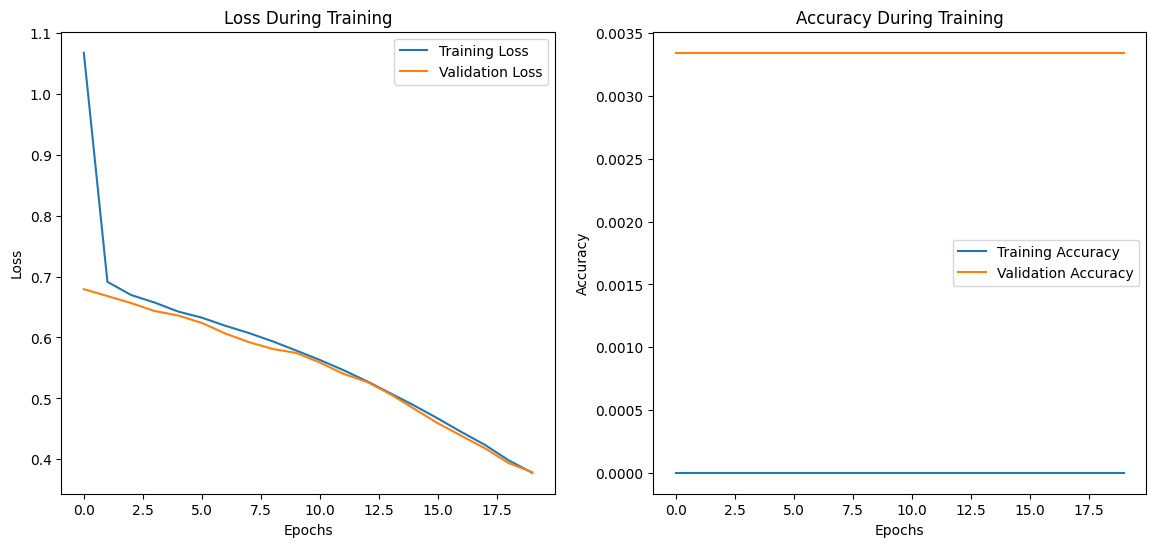

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ✅ CNN Model Definition
def build_cnn_model(input_shape=(256, 256, 3)):
    model = Sequential()

    # Encoder
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    # Decoder
    model.add(UpSampling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(UpSampling2D((2, 2)))
    model.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ✅ Instantiate and compile the model
cnn_model = build_cnn_model()

# ✅ Model summary
cnn_model.summary()

# ✅ Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("shoreline_cnn_model.h5", save_best_only=True)

# ✅ Train the model
history = cnn_model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=20,
    batch_size=8,
    callbacks=[early_stopping, model_checkpoint]
)

# ✅ Plot the training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ✅ Loss plot
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss During Training')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# ✅ Accuracy plot
ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy During Training')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

## New method

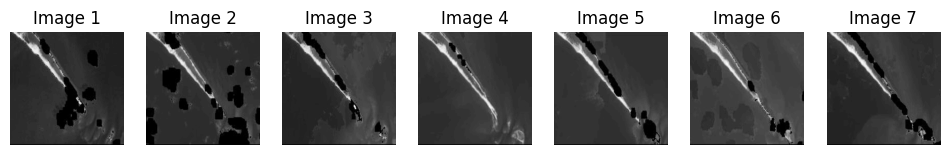

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ Specify image paths (replace with your file paths)
image_paths = [
    "Landsat_CloudFree_2010_Month_1.jpg",
    "Landsat_CloudFree_2013_Month_3.jpg",
    "Landsat_CloudFree_2014_Month_1.jpg",
    "Landsat_CloudFree_2015_Month_1.jpg",
    "Landsat_CloudFree_2016_Month_1.jpg",
    "Landsat_CloudFree_2018_Month_1.jpg",
    "Landsat_CloudFree_2019_Month_1.jpg"  # Add more paths as needed
]

# ✅ Load and preprocess images
def load_images(image_paths, target_size=(256, 256)):
    images = []
    
    for path in image_paths:
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                resized = cv2.resize(gray, target_size)
                images.append(resized)
            else:
                print(f"⚠️ Failed to load image: {path}")
        else:
            print(f"❌ Invalid path: {path}")
    
    return np.array(images)

# ✅ Load and visualize
images = load_images(image_paths)

# Display the preprocessed images
fig, axes = plt.subplots(1, len(images), figsize=(12, 6))
for i, img in enumerate(images):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Image {i + 1}")
    axes[i].axis('off')
plt.show()


In [29]:
import os
import cv2
import numpy as np

# ✅ Folder paths
image_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"
target_size = (256, 256)

# ✅ Function to load and resize images and masks
def load_data(image_folder, mask_folder, size=(256, 256)):
    images, masks = [], []

    for filename in os.listdir(image_folder):
        img_path = os.path.join(image_folder, filename)
        mask_path = os.path.join(mask_folder, filename)

        if not os.path.exists(mask_path):
            continue  # Skip if mask is missing

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue

        # ✅ Resize both images and masks to the same dimensions
        img_resized = cv2.resize(img, size) / 255.0
        mask_resized = cv2.resize(mask, size) / 255.0

        images.append(img_resized)
        masks.append(mask_resized)

    return np.array(images), np.array(masks)

# ✅ Load and resize data
X, Y = load_data(image_folder, mask_folder, target_size)

print(f"✅ Loaded {len(X)} images and {len(Y)} masks. Shape: {X.shape}")


✅ Loaded 38 images and 38 masks. Shape: (38, 256, 256)


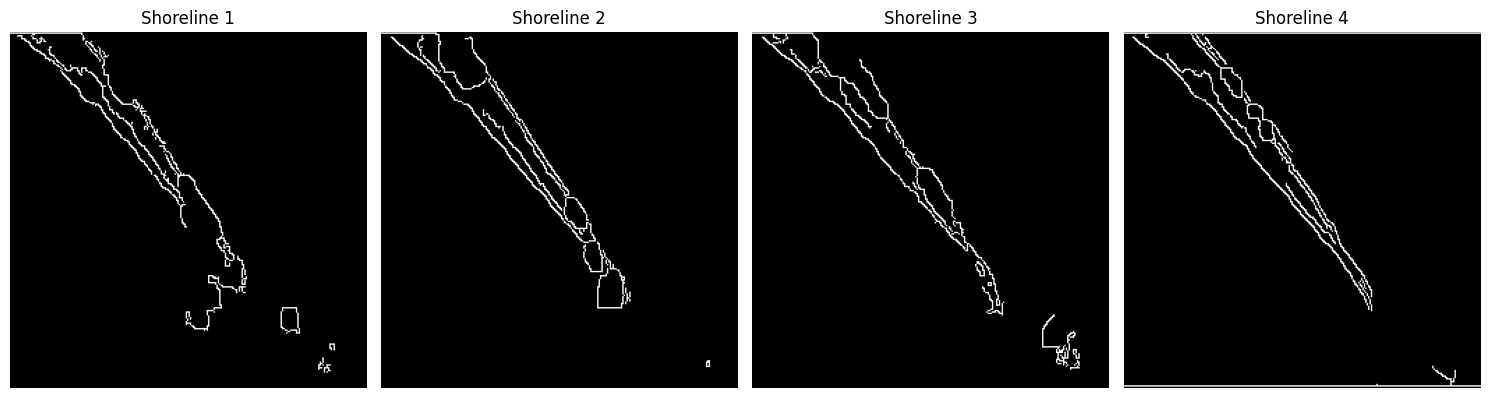

In [30]:
import matplotlib.pyplot as plt

# ✅ Function to detect shoreline using Canny edge detection
def detect_shoreline(image):
    # Convert to 8-bit grayscale for Canny compatibility
    img_8bit = (image * 255).astype(np.uint8)  
    edges = cv2.Canny(img_8bit, 50, 150)  # Detect edges
    return edges

# ✅ Apply shoreline detection to all images
shorelines = np.array([detect_shoreline(img) for img in X])

# ✅ Display sample results
num_samples = min(4, len(shorelines))
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i in range(num_samples):
    axes[i].imshow(shorelines[i], cmap='gray')
    axes[i].set_title(f"Shoreline {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


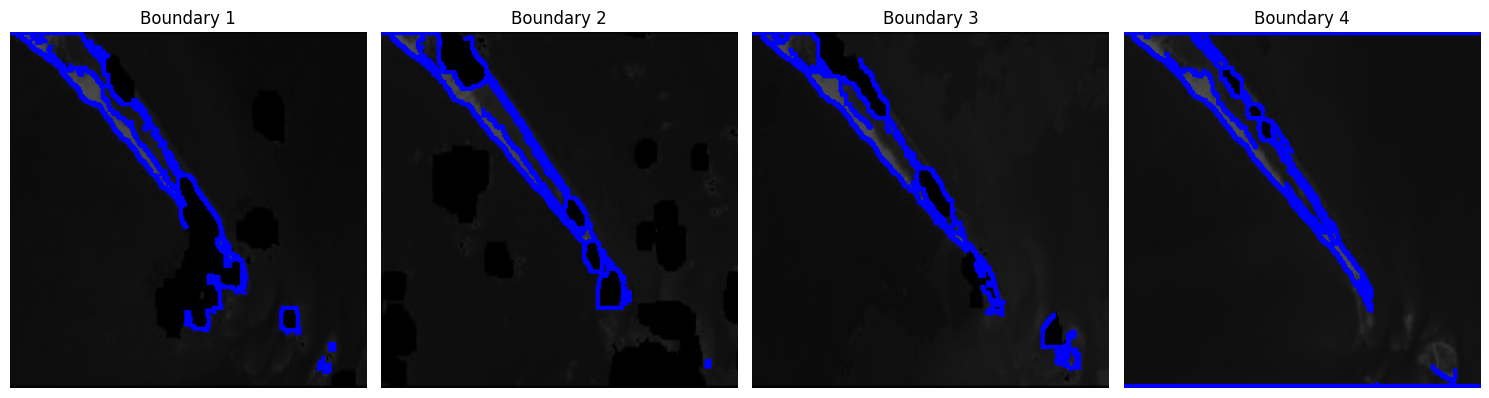

In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ✅ Function to create boundary mask with proper broadcasting
def create_boundary(image, shoreline):
    # Convert image and shoreline mask to uint8
    image_uint8 = (image * 255).astype(np.uint8)
    shoreline_uint8 = (shoreline * 255).astype(np.uint8)

    # Resize shoreline mask to match image dimensions
    shoreline_resized = cv2.resize(shoreline_uint8, (image_uint8.shape[1], image_uint8.shape[0]))

    # Create boundary mask
    boundary_mask = cv2.dilate(shoreline_resized, np.ones((3, 3), np.uint8), iterations=1)

    # Create a red-colored boundary mask
    boundary_image = cv2.cvtColor(image_uint8, cv2.COLOR_GRAY2BGR)  # Ensure 3 channels
    boundary_image[boundary_mask > 0] = [255, 0, 0]  # Red boundary

    return boundary_image

# ✅ Apply boundary creation to all images
boundary_images = []
for i, img in enumerate(X):
    shoreline_resized = cv2.resize(shorelines[i], (img.shape[1], img.shape[0]))  # Resize shoreline mask
    boundary_img = create_boundary(img, shoreline_resized)
    boundary_images.append(boundary_img)

# ✅ Display sample boundary results
num_samples = min(4, len(boundary_images))
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i in range(num_samples):
    axes[i].imshow(cv2.cvtColor(boundary_images[i], cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Boundary {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


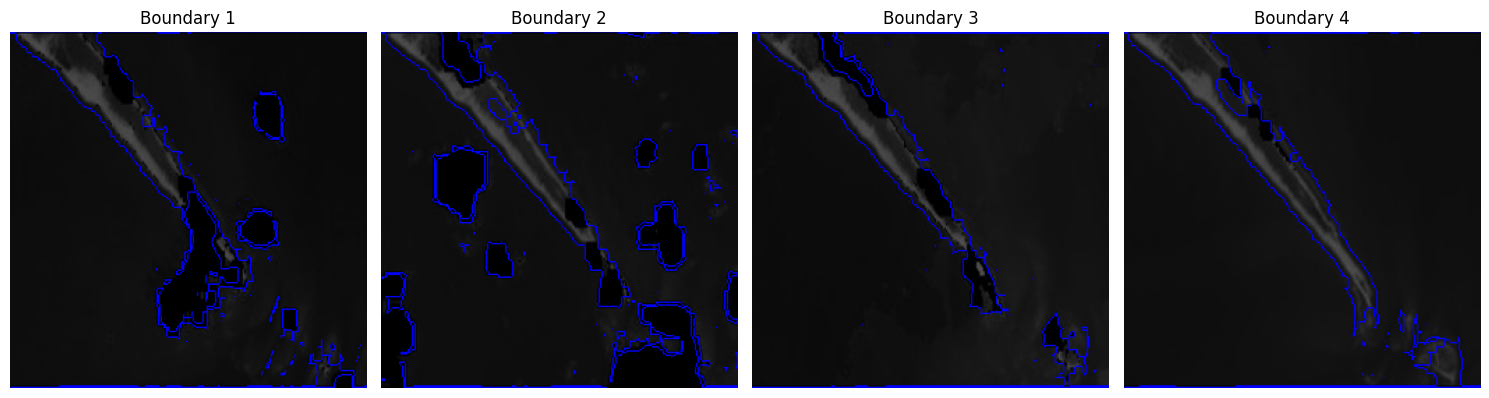

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ✅ Improved shoreline detection function
def improved_shoreline_detection(image):
    # Convert image to uint8 format
    img_uint8 = (image * 255).astype(np.uint8)
    
    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(img_uint8, (5, 5), 0)
    
    # Adaptive thresholding for better segmentation
    threshold = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY_INV, 11, 2)

    # Morphological operations to clean noise
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(threshold, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Contour detection for shoreline
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create mask for boundary visualization
    boundary_mask = np.zeros_like(img_uint8)
    cv2.drawContours(boundary_mask, contours, -1, (255), thickness=1)

    return boundary_mask

# ✅ Apply shoreline detection on all images
boundary_images = []
for img in X:
    boundary_mask = improved_shoreline_detection(img)
    
    # Convert image to RGB for boundary overlay
    img_rgb = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    
    # Apply red boundary overlay
    img_rgb[boundary_mask > 0] = [255, 0, 0]
    
    boundary_images.append(img_rgb)

# ✅ Display sample boundary results
num_samples = min(4, len(boundary_images))
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i in range(num_samples):
    axes[i].imshow(cv2.cvtColor(boundary_images[i], cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Boundary {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


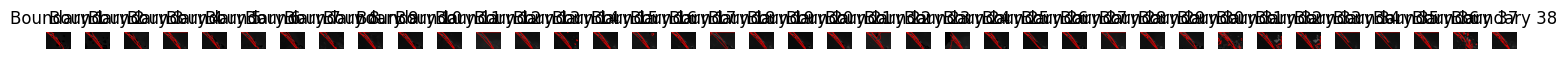

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ Set image and mask directories
image_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
mask_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"

# ✅ Load images and masks
image_files = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')])
mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.jpg')])

# ✅ Ensure matching pairs
if len(image_files) != len(mask_files):
    print("⚠️ Mismatched image and mask count!")
    exit()

# ✅ Read images and masks
images = [cv2.imread(img, cv2.IMREAD_GRAYSCALE) for img in image_files]
masks = [cv2.imread(mask, cv2.IMREAD_GRAYSCALE) for mask in mask_files]

# ✅ Boundary creation function
def create_boundary(image, mask):
    # Ensure both image and mask are uint8
    image = np.uint8(image)
    mask = np.uint8(mask)

    # Convert mask to binary
    _, binary_mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw red boundaries on the original image
    boundary_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(boundary_image, contours, -1, (0, 0, 255), 2)

    return boundary_image

# ✅ Display images with boundaries
fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

for i, (img, mask) in enumerate(zip(images, masks)):
    boundary_image = create_boundary(img, mask)

    axes[i].imshow(cv2.cvtColor(boundary_image, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Boundary {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [34]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# ✅ Prepare the data
def prepare_data(images, masks):
    """
    Flattens images and masks into feature and label arrays for ML models.
    """
    X = np.array([img.flatten() for img in images])
    y = np.array([1 if np.mean(mask) > 128 else 0 for mask in masks])  # Binary labels: land = 1, sea = 0
    return X, y

# ✅ Flatten image and mask data
X, y = prepare_data(images, masks)

# ✅ Print label distribution to check for imbalance
unique, counts = np.unique(y, return_counts=True)
print("\n🔥 Label Distribution:")
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples")

# ✅ Split into training and testing sets with more test samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

# ✅ Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# ✅ Train XGBoost model with regularization to avoid overfitting
xgb_model = XGBClassifier(
    n_estimators=50, 
    max_depth=5,                # Reduce complexity
    learning_rate=0.1,           # Use smaller learning rate
    min_child_weight=5,          # Prevent overfitting
    subsample=0.8,               # Use 80% of data per tree
    colsample_bytree=0.8,        # Use 80% of features per tree
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss',
    base_score=0.5
)
xgb_model.fit(X_train, y_train)

# ✅ Predictions
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# ✅ Evaluation
print("\n🔥 Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\n🔥 XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))
print("Accuracy:", accuracy_score(y_test, xgb_pred))



🔥 Label Distribution:
Class 0: 38 samples

🔥 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Accuracy: 1.0

🔥 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Accuracy: 1.0


✅ Mask saved: mask_Landsat_CloudFree_2010_Month_1.jpg
✅ Mask saved: mask_Landsat_CloudFree_2013_Month_3.jpg
✅ Mask saved: mask_Landsat_CloudFree_2014_Month_1.jpg
✅ Mask saved: mask_Landsat_CloudFree_2015_Month_1.jpg
✅ Mask saved: mask_Landsat_CloudFree_2016_Month_1.jpg


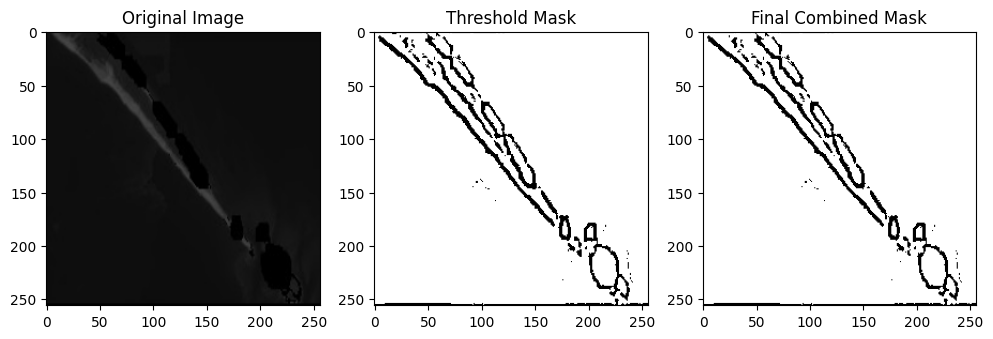

✅ Mask saved: mask_Landsat_CloudFree_2018_Month_1.jpg
✅ Mask saved: mask_Landsat_CloudFree_2019_Month_1.jpg
✅ Mask saved: mask_Landsat_CloudFree_2020_Month_11.jpg
✅ Mask saved: mask_Landsat_CloudFree_2020_Month_12.jpg
✅ Mask saved: mask_Landsat_CloudFree_2020_Month_2.jpg


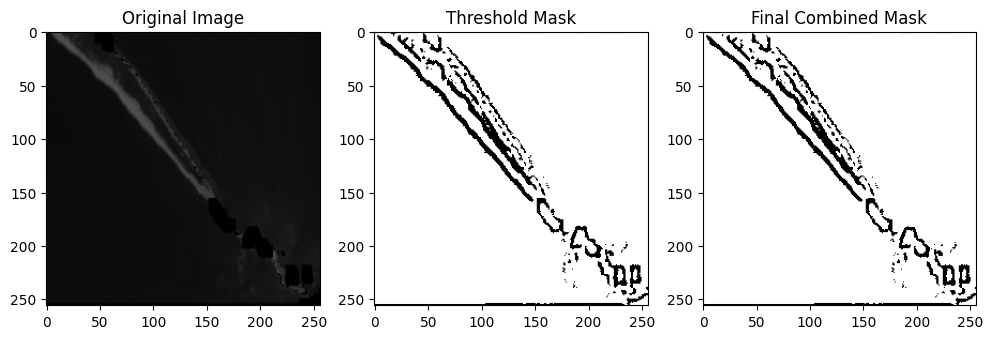

✅ Mask saved: mask_Landsat_CloudFree_2020_Month_4.jpg
✅ Mask saved: mask_Landsat_CloudFree_2020_Month_5.jpg
✅ Mask saved: mask_Landsat_CloudFree_2020_Month_6.jpg
✅ Mask saved: mask_Landsat_CloudFree_2021_Month_11.jpg
✅ Mask saved: mask_Landsat_CloudFree_2021_Month_3.jpg


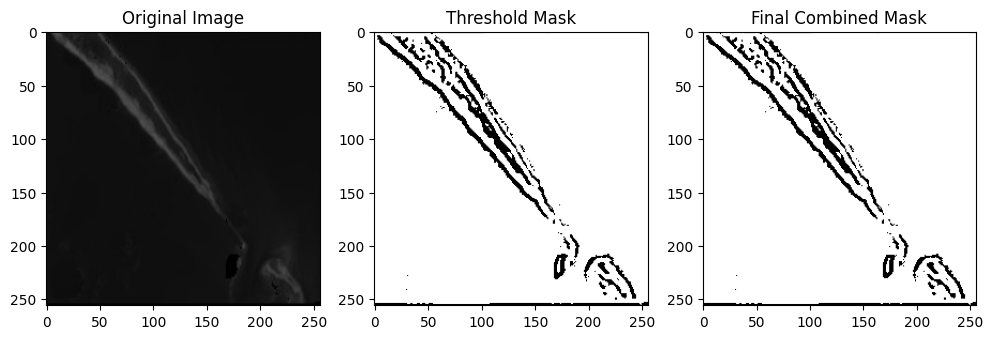

✅ Mask saved: mask_Landsat_CloudFree_2021_Month_4.jpg
✅ Mask saved: mask_Landsat_CloudFree_2021_Month_5.jpg
✅ Mask saved: mask_Landsat_CloudFree_2021_Month_6.jpg
✅ Mask saved: mask_Landsat_CloudFree_2021_Month_7.jpg
✅ Mask saved: mask_Landsat_CloudFree_2022_Month_2.jpg


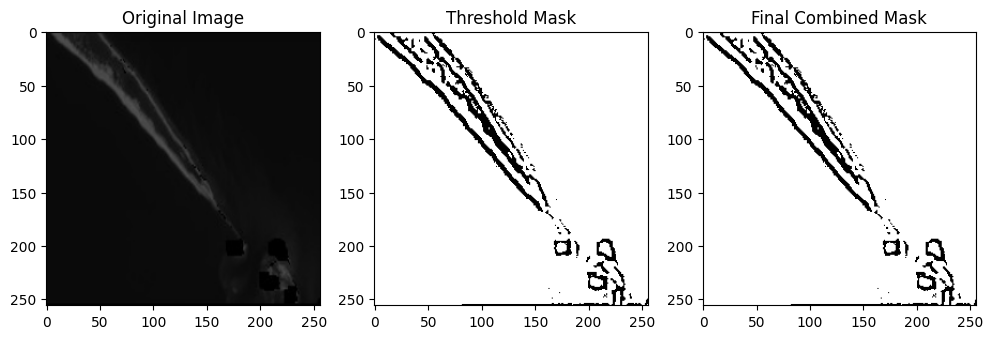

✅ Mask saved: mask_Landsat_CloudFree_2022_Month_4.jpg
✅ Mask saved: mask_Landsat_CloudFree_2022_Month_5.jpg
✅ Mask saved: mask_Landsat_CloudFree_2022_Month_6.jpg
✅ Mask saved: mask_Landsat_CloudFree_2022_Month_7.jpg
✅ Mask saved: mask_Landsat_CloudFree_2023_Month_1.jpg


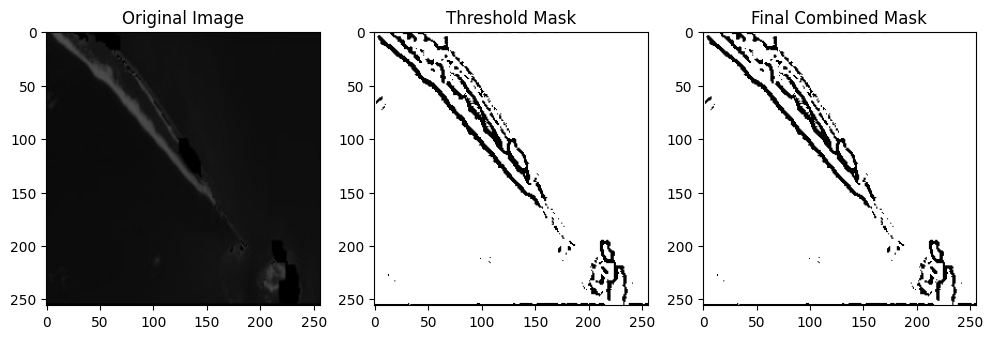

✅ Mask saved: mask_Landsat_CloudFree_2023_Month_11.jpg
✅ Mask saved: mask_Landsat_CloudFree_2023_Month_2.jpg
✅ Mask saved: mask_Landsat_CloudFree_2023_Month_4.jpg
✅ Mask saved: mask_Landsat_CloudFree_2023_Month_6.jpg
✅ Mask saved: mask_Landsat_CloudFree_2023_Month_8.jpg


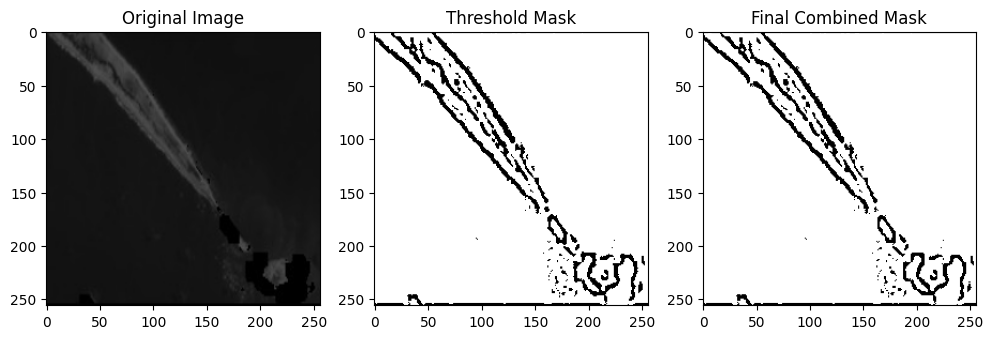

✅ Mask saved: mask_Landsat_CloudFree_2023_Month_9.jpg
✅ Mask saved: mask_Landsat_CloudFree_2024_Month_1 (1).jpg
✅ Mask saved: mask_Landsat_CloudFree_2024_Month_1.jpg
✅ Mask saved: mask_Landsat_CloudFree_2024_Month_12 (1).jpg
✅ Mask saved: mask_Landsat_CloudFree_2024_Month_12.jpg


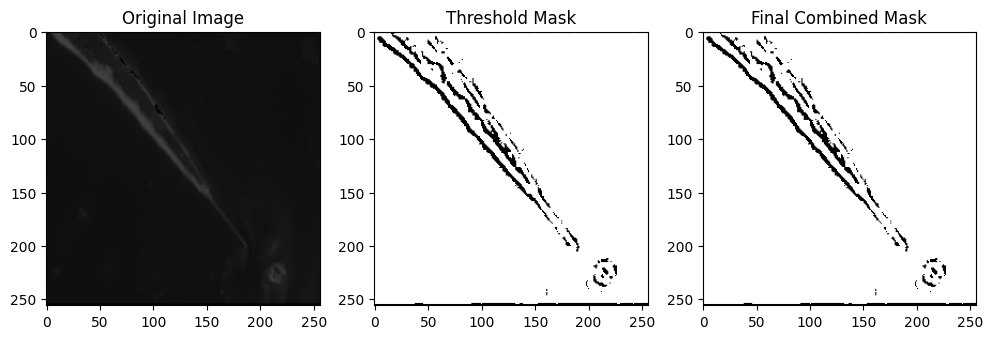

✅ Mask saved: mask_Landsat_CloudFree_2024_Month_3.jpg
✅ Mask saved: mask_Landsat_CloudFree_2024_Month_4.jpg
✅ Mask saved: mask_Landsat_CloudFree_2024_Month_9.jpg
✅ Completed mask generation for 38 images!


In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ Input and Output Folders
source_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
output_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"

# ✅ Create output directory if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# ✅ Target shape for resizing
target_shape = (256, 256)

# ✅ Batch Processing of Images
def generate_masks(source_folder, output_folder):
    image_count = 0

    for img_name in os.listdir(source_folder):
        if img_name.lower().endswith(('.jpg', '.png', '.tif', '.jpeg')):
            
            img_path = os.path.join(source_folder, img_name)

            # ✅ Read image
            img = cv2.imread(img_path)
            if img is None:
                print(f"⚠️ Skipping {img_name} - Unable to load.")
                continue

            # ✅ Resize image
            img_resized = cv2.resize(img, target_shape, interpolation=cv2.INTER_LINEAR)

            # ✅ Convert to grayscale
            gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

            # ✅ Apply Gaussian Blur
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)

            # ✅ Apply adaptive thresholding
            mask_thresh = cv2.adaptiveThreshold(
                blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY, 11, 2
            )

            # ✅ Apply Canny edge detection
            edges = cv2.Canny(blurred, 50, 150)

            # ✅ Combine threshold and edge mask
            combined_mask = cv2.bitwise_or(mask_thresh, edges)

            # ✅ Save mask in output folder
            mask_name = f"mask_{img_name}"
            mask_path = os.path.join(output_folder, mask_name)
            cv2.imwrite(mask_path, combined_mask)

            print(f"✅ Mask saved: {mask_name}")
            image_count += 1

            # ✅ Display sample result every 5 images
            if image_count % 5 == 0:
                plt.figure(figsize=(12, 6))

                plt.subplot(1, 3, 1)
                plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
                plt.title("Original Image")

                plt.subplot(1, 3, 2)
                plt.imshow(mask_thresh, cmap='gray')
                plt.title("Threshold Mask")

                plt.subplot(1, 3, 3)
                plt.imshow(combined_mask, cmap='gray')
                plt.title("Final Combined Mask")

                plt.show()

    print(f"✅ Completed mask generation for {image_count} images!")

# ✅ Run the batch processing
generate_masks(source_folder, output_folder)


In [28]:
import os
import cv2
import numpy as np
from glob import glob

# Define directories
input_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"         # Directory for input images
mask_dir = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"           # Empty folder for masks
output_dir = 'processed'    # Output folder for preprocessed images

# Create output folders if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# Set target image size
image_size = (256, 256)

# Function to preprocess images (resize, grayscale, normalize)
def preprocess_images(image_folder, output_folder, image_size):
    for img_path in glob(f"{image_folder}/*.jpg"):
        img = cv2.imread(img_path)

        # Resize image
        img_resized = cv2.resize(img, image_size)

        # Convert to grayscale
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        # Normalize pixel values
        normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

        # Save preprocessed image
        output_path = os.path.join(output_folder, os.path.basename(img_path))
        cv2.imwrite(output_path, normalized)

        print(f"✅ Processed: {os.path.basename(img_path)}")

# Function to create masks using edge detection
def create_masks(input_folder, mask_folder):
    for img_path in glob(f"{input_folder}/*.jpg"):
        img = cv2.imread(img_path)

        # Resize and convert to grayscale
        img_resized = cv2.resize(img, image_size)
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        # Apply Canny edge detection
        edges = cv2.Canny(gray, 50, 150)

        # Save mask
        mask_path = os.path.join(mask_folder, os.path.basename(img_path))
        cv2.imwrite(mask_path, edges)
        
        print(f"✅ Mask created: {os.path.basename(img_path)}")

# Preprocess images
print("\n📌 Preprocessing Input Images...")
preprocess_images(input_dir, output_dir, image_size)

# Create masks
print("\n📌 Creating Masks...")
create_masks(input_dir, mask_dir)

print("\n✅ Preprocessing and mask creation completed.")



📌 Preprocessing Input Images...
✅ Processed: Landsat_CloudFree_2010_Month_1.jpg
✅ Processed: Landsat_CloudFree_2013_Month_3.jpg
✅ Processed: Landsat_CloudFree_2014_Month_1.jpg
✅ Processed: Landsat_CloudFree_2015_Month_1.jpg
✅ Processed: Landsat_CloudFree_2016_Month_1.jpg
✅ Processed: Landsat_CloudFree_2018_Month_1.jpg
✅ Processed: Landsat_CloudFree_2019_Month_1.jpg
✅ Processed: Landsat_CloudFree_2020_Month_11.jpg
✅ Processed: Landsat_CloudFree_2020_Month_12.jpg
✅ Processed: Landsat_CloudFree_2020_Month_2.jpg
✅ Processed: Landsat_CloudFree_2020_Month_4.jpg
✅ Processed: Landsat_CloudFree_2020_Month_5.jpg
✅ Processed: Landsat_CloudFree_2020_Month_6.jpg
✅ Processed: Landsat_CloudFree_2021_Month_11.jpg
✅ Processed: Landsat_CloudFree_2021_Month_3.jpg
✅ Processed: Landsat_CloudFree_2021_Month_4.jpg
✅ Processed: Landsat_CloudFree_2021_Month_5.jpg
✅ Processed: Landsat_CloudFree_2021_Month_6.jpg
✅ Processed: Landsat_CloudFree_2021_Month_7.jpg
✅ Processed: Landsat_CloudFree_2022_Month_2.jpg
✅ Pr